|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 5:</h2>|<h1>Making It Fast<h1>|
|<h2>Section:</h2>|<h1>CUDA graphs<h1>|
|<h2>Lecture:</h2>|<h1><b>The CPU as the bottleneck, and how to take it out of the loop<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

import sys
from pathlib import Path
ROOT = next(folder for folder in [Path.cwd(), *Path.cwd().parents]
            if (folder/'cudalib').is_dir())
sys.path.insert(0, str(ROOT))

import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import cudalib

# The Python tax

A decode step at batch 1 is about a millisecond of GPU work. It is also
several hundred separate kernel launches, and each launch costs the CPU a few
microseconds to issue.

Multiply that out and the CPU can easily be the slower of the two. The GPU
then spends its time waiting for instructions rather than for memory, which
no kernel optimisation will fix.

In [2]:
class Layer(nn.Module):
  """One transformer layer, shaped like a decode step: many small kernels."""
  def __init__(self, hidden):
    super().__init__()
    self.attention_norm = nn.RMSNorm(hidden)
    self.qkv_proj = nn.Linear(hidden, 3*hidden, bias=False)
    self.out_proj = nn.Linear(hidden, hidden, bias=False)
    self.mlp_norm = nn.RMSNorm(hidden)
    self.up_proj = nn.Linear(hidden, 4*hidden, bias=False)
    self.down_proj = nn.Linear(4*hidden, hidden, bias=False)

  def forward(self, hidden_states):
    normed = self.attention_norm(hidden_states)
    query, key, value = self.qkv_proj(normed).chunk(3, -1)
    scores = query @ key.transpose(-1, -2) / 32.0
    attention = torch.softmax(scores, -1) @ value
    hidden_states = hidden_states + self.out_proj(attention)
    normed = self.mlp_norm(hidden_states)
    return hidden_states + self.down_proj(F.silu(self.up_proj(normed)))

class Model(nn.Module):
  def __init__(self, num_layers=28, hidden=1024):
    super().__init__()
    self.layers = nn.ModuleList([Layer(hidden) for _ in range(num_layers)])

  def forward(self, hidden_states):
    for layer in self.layers:
      hidden_states = layer(hidden_states)
    return hidden_states

HIDDEN, LAYERS = 1024, 28

def random_input(num_seqs, hidden=HIDDEN):
  """The hidden states of one decode step: one token for each sequence."""
  return torch.randn(num_seqs, 1, hidden, device='cuda', dtype=torch.bfloat16)

In [3]:
model = Model(LAYERS, HIDDEN).cuda().to(torch.bfloat16).eval()
kernels_per_layer = 9    # norm, qkv, chunk, matmul, softmax, matmul, out, norm, mlp...
num_launches = LAYERS * kernels_per_layer
print(f'{LAYERS} layers x approximately {kernels_per_layer} kernels = '
      f'~{num_launches} launches for each step')
print(f'at 5 microseconds each, that is {num_launches*5/1000:.2f} ms only to issue them')

28 layers x approximately 9 kernels = ~252 launches for each step
at 5 microseconds each, that is 1.26 ms only to issue them


### Separate the two clocks

A CUDA launch is asynchronous. It returns before the kernel runs. So time the
enqueue with no synchronise. Then time the same work with a synchronise. The
difference tells you which side you wait for.

In [4]:
step_input = random_input(1)

@torch.no_grad()
def issue_ms(iters=50):
  """The CPU time to issue one step. No synchronize inside: only the issue."""
  torch.cuda.synchronize()
  start = time.perf_counter()
  for _ in range(iters):
    model(step_input)
  elapsed_ms = (time.perf_counter() - start) / iters * 1000
  torch.cuda.synchronize()
  return elapsed_ms

with torch.no_grad():
  step_ms = cudalib.bench_ms(lambda: model(step_input), iters=50, warmup=20, best_of=2)
cpu_ms = issue_ms()
print(f'CPU time to issue one step: {cpu_ms:7.3f} ms')
print(f'wall clock for one step:    {step_ms:7.3f} ms')
print(f'\nthe CPU is busy for {100*cpu_ms/step_ms:.0f}% of the step')

CPU time to issue one step:   5.109 ms
wall clock for one step:      5.076 ms

the CPU is busy for 101% of the step


# Record it one time, replay it forever

A CUDA graph captures the whole sequence of launches, with their arguments and
their dependencies, into one object. One call then replays it.

The price is that everything is frozen. You get the same pointers, the same
shapes and the same kernels, every time.

In [5]:
def capture(model, example):
  """Record one forward pass as a graph.
  -> (graph, static_input, static_output).

  Warm up on a side stream first. cuBLAS allocates workspaces on the first
  call, and the graph must not record that allocation.
  """
  static_input = example.clone()
  side_stream = torch.cuda.Stream()
  side_stream.wait_stream(torch.cuda.current_stream())
  with torch.cuda.stream(side_stream):
    for _ in range(3):
      model(static_input)
  torch.cuda.current_stream().wait_stream(side_stream)
  graph = torch.cuda.CUDAGraph()
  with torch.cuda.graph(graph):
    static_output = model(static_input)
  return graph, static_input, static_output

In [6]:
with torch.no_grad():
  graph, static_input, static_output = capture(model, step_input)
  eager_ms = cudalib.bench_ms(lambda: model(step_input), iters=50, warmup=20, best_of=3)
graph_ms = cudalib.bench_ms(lambda: graph.replay(), iters=50, warmup=20, best_of=3)
print(f'eager:  {eager_ms:7.3f} ms')
print(f'graph:  {graph_ms:7.3f} ms')
print(f'\n{eager_ms/graph_ms:.2f}x, and the difference is the '
      f'{eager_ms-graph_ms:.2f} ms that the CPU used')

eager:    4.357 ms
graph:    2.581 ms

1.69x, and the difference is the 1.78 ms that the CPU used


### How to use the result

Replay writes into the same output tensor every time. So copy your real input
into `static_input`, replay, and read `static_output`. Nothing else can move.

In [7]:
real_input = random_input(1)
static_input.copy_(real_input)    # in place. The graph does not see a new tensor.
graph.replay()
from_graph = static_output.clone()
with torch.no_grad():
  from_eager = model(real_input)
print('graph and eager agree:',
      torch.allclose(from_graph, from_eager, rtol=1e-2, atol=1e-2))

graph and eager agree: True


# Where the win comes from, and where it goes

In [8]:
print(f"{'hidden size':>12} {'eager ms':>10} {'graph ms':>10} {'speedup':>8}")
rows = []
for hidden in (256, 512, 1024, 2048):
  sized_model = Model(LAYERS, hidden).cuda().to(torch.bfloat16).eval()
  sized_input = random_input(1, hidden)
  with torch.no_grad():
    eager_ms = cudalib.bench_ms(lambda: sized_model(sized_input),
                                iters=50, warmup=20, best_of=2)
    sized_graph, _, _ = capture(sized_model, sized_input)
  graph_ms = cudalib.bench_ms(lambda: sized_graph.replay(),
                              iters=50, warmup=20, best_of=2)
  rows.append((hidden, eager_ms, graph_ms))
  print(f'{hidden:>12} {eager_ms:>10.3f} {graph_ms:>10.3f} {eager_ms/graph_ms:>7.2f}x')
  del sized_model, sized_graph
  torch.cuda.empty_cache()

 hidden size   eager ms   graph ms  speedup


         256      4.345      0.637    6.82x


         512      4.511      1.316    3.43x


        1024      5.043      2.575    1.96x


        2048      8.661      9.609    0.90x


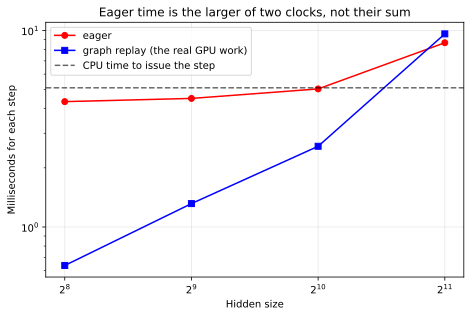

hidden   256: GPU work  0.637 ms, eager  4.345 ms -> CPU-bound
hidden   512: GPU work  1.316 ms, eager  4.511 ms -> CPU-bound
hidden  1024: GPU work  2.575 ms, eager  5.043 ms -> CPU-bound
hidden  2048: GPU work  9.609 ms, eager  8.661 ms -> GPU-bound


In [9]:
results = np.array(rows)
plt.figure(figsize=(7.5,4.6))
plt.plot(results[:,0], results[:,1], 'ro-', label='eager')
plt.plot(results[:,0], results[:,2], 'bs-', label='graph replay (the real GPU work)')
plt.axhline(cpu_ms, color='k', ls='--', alpha=.6, label='CPU time to issue the step')
plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('Hidden size')
plt.ylabel('Milliseconds for each step')
plt.title('Eager time is the larger of two clocks, not their sum')
plt.legend()
plt.grid(alpha=.3)
plt.show()
for hidden, eager_ms, graph_ms in rows:
  bound = 'CPU' if graph_ms < cpu_ms else 'GPU'
  print(f'hidden {hidden:>5}: GPU work {graph_ms:6.3f} ms, '
        f'eager {eager_ms:6.3f} ms -> {bound}-bound')

### The eager line is flat, and that is the whole story

Look at the red line from 256 to 1024. The model became sixteen times larger,
and the step took the same time.

The reason is that launches are asynchronous. The CPU issues the next kernel
while the GPU runs the last one. So a step does not cost `cpu_ms + gpu_ms`. It costs
approximately **the larger of the two**. Until the GPU work passes the dashed
line, the GPU waits for instructions.

The blue line shows what the hardware can do. The gap to the red line is work
that you paid for and did not get.

So CUDA graphs give the most benefit at the exact point where you need them
most: a small model at a small batch. The benefit goes to zero when the GPU
work becomes larger than the cost to issue it. At a hidden size of 2048 the speedup is a
rounding error, and the capture does not earn its memory.

This also tells you when to stop work on your kernels. If you are on the left
of that dashed line, a faster kernel gives you nothing.

    ./vc guide 12